In [1]:
import anndata as an
import scanpy as sc
import pandas as pd
import numpy as np
import os
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import gget

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
fpaths = {
    'control' : "/scratch/indikar_root/indikar1/shared_data/sc_cell_cycle/anndata/anndata.raw.h5ad",
    'hybrid' : "/scratch/indikar_root/indikar1/shared_data/lib2_02262025/anndata/anndata.raw.h5ad",
}

adata = []

for key, fpath in fpaths.items():
    tdata = sc.read_h5ad(fpath)
    tdata.obs['batch'] = key
    tdata.obs_names = [f"{x}_{key}" for x in tdata.obs_names] # make sure ids are consistent
    adata.append(tdata)

    print(f"Batch: {key}")
    print(f"\tTotal UMIs: {int(np.sum(tdata.X))}")
    print(f"\tCells: {tdata.shape[0]}")
    print(f"\tGenes: {tdata.shape[1]}")

    df = tdata.to_df()
    print(f"\tMean reads per cell: {int(df.sum(axis=1).mean())}")
    print(f"\tMean reads per gene: {int(df.sum(axis=0).mean())}")

    df_bool = df.astype(bool)
    
    print(f"\tMean genes per cell: {int(df_bool.sum(axis=1).mean())}")
    print(f"\tMean cells per gene: {int(df_bool.sum(axis=0).mean())}")

    if key == 'hybrid':
        gene_map = dict(zip(tdata.var_names, tdata.var['gene_name']))

adata = an.concat(adata)
adata.var['gene_name'] = adata.var.index.map(gene_map)
adata.var_names = adata.var['gene_name'].values

adata

Batch: control
	Total UMIs: 122599800
	Cells: 10747
	Genes: 41389
	Mean reads per cell: 11407
	Mean reads per gene: 2962
	Mean genes per cell: 2555
	Mean cells per gene: 663
Batch: hybrid
	Total UMIs: 107184032
	Cells: 11641
	Genes: 41389
	Mean reads per cell: 9207
	Mean reads per gene: 2589
	Mean genes per cell: 2701
	Mean cells per gene: 759


AnnData object with n_obs × n_vars = 22388 × 41389
    obs: 'batch'
    var: 'gene_name'

In [3]:
def filter_nan_inf_anndata(adata, replace_value=0):
    """
    Filters NaN and inf values in anndata.X, replacing them with a specified value.

    Args:
        adata (anndata.AnnData): The AnnData object.
        replace_value (float or int): The value to replace NaN and inf values with. Defaults to 0.

    Returns:
        anndata.AnnData: The AnnData object with filtered X.
    """

    if issparse(adata.X):
        # Convert to COO format for easier manipulation
        coo_mat = adata.X.tocoo()
        data = coo_mat.data

        # Find NaN and inf values
        nan_inf_mask = np.isnan(data) | np.isinf(data)

        if np.any(nan_inf_mask):
            # Replace NaN and inf values
            data[nan_inf_mask] = replace_value

            # Reconstruct the sparse matrix
            adata.X = csr_matrix((data, (coo_mat.row, coo_mat.col)), shape=adata.X.shape)

    else:
        # Dense matrix case
        nan_inf_mask = np.isnan(adata.X) | np.isinf(adata.X)
        adata.X[nan_inf_mask] = replace_value

    return adata

adata = filter_nan_inf_anndata(adata, replace_value=0)
adata

AnnData object with n_obs × n_vars = 22388 × 41389
    obs: 'batch'
    var: 'gene_name'

# Aggregate Differences

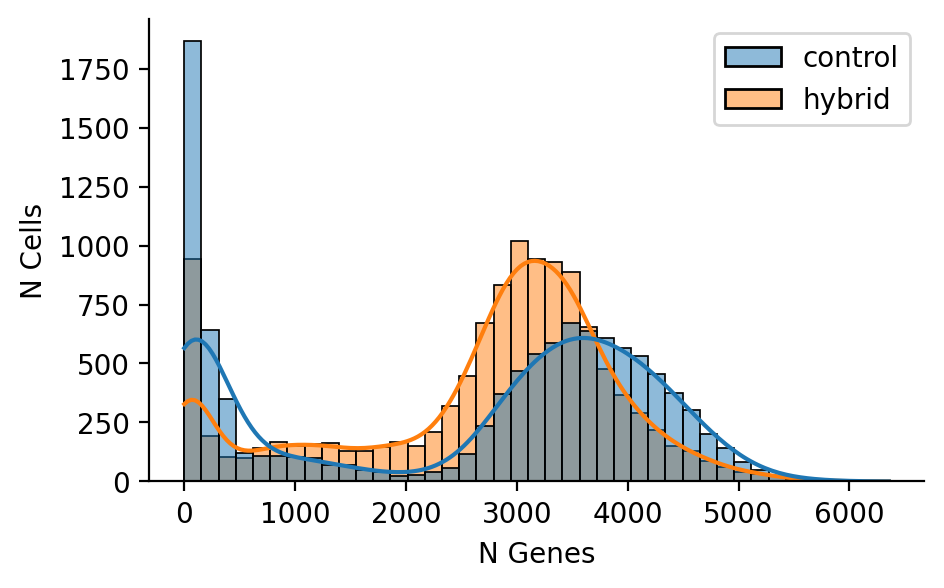

In [4]:
adata.obs['n_genes'] = np.diff(adata.X.indptr)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.histplot(
    data=adata.obs,
    bins=41,
    x='n_genes',
    hue='batch',
    kde=True,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='best',
)
plt.ylabel('N Cells')
plt.xlabel('N Genes')

sns.despine()

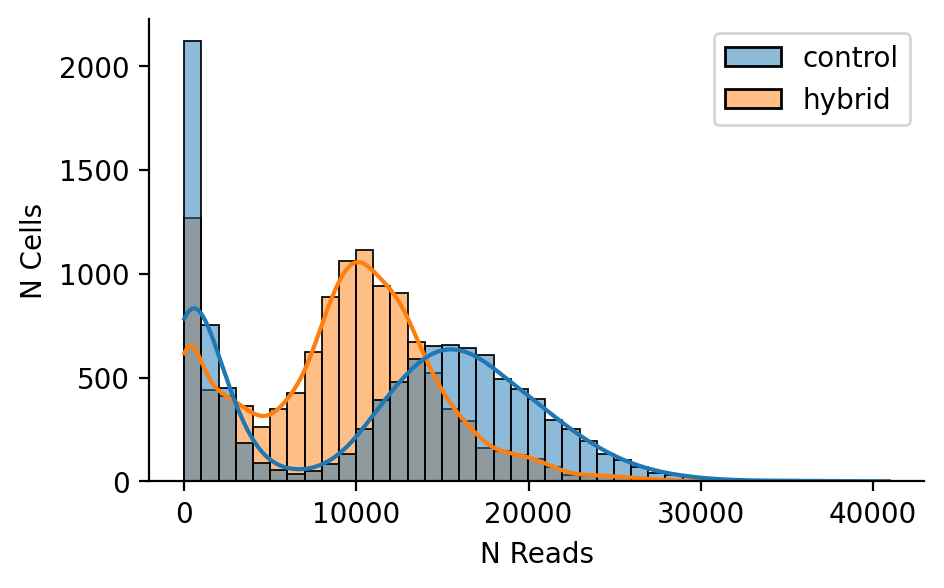

In [5]:
adata.obs['n_reads'] = adata.X.sum(axis=1)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 3

sns.histplot(
    data=adata.obs,
    bins=41,
    x='n_reads',
    hue='batch',
    kde=True,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='best',
)
plt.ylabel('N Cells')
plt.xlabel('N Reads')

sns.despine()

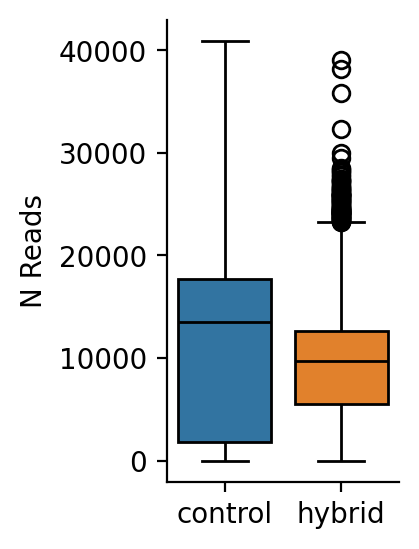

In [6]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 1.5, 3

sns.boxplot(
    data=adata.obs,
    x='batch',
    hue='batch',
    y='n_reads',
    linecolor='k',
)

plt.xlabel('')
plt.ylabel('N Reads')

sns.despine()

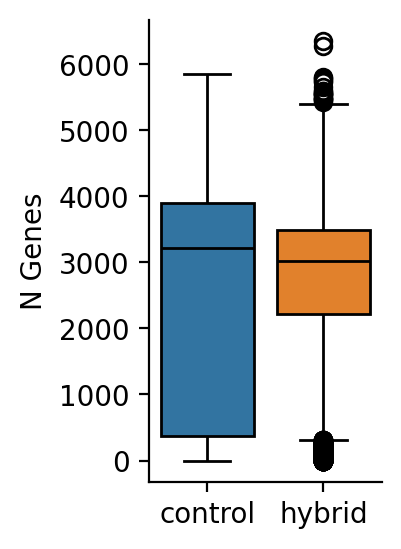

In [7]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 1.5, 3

sns.boxplot(
    data=adata.obs,
    x='batch',
    hue='batch',
    y='n_genes',
    linecolor='k',
)

plt.xlabel('')
plt.ylabel('N Genes')

sns.despine()

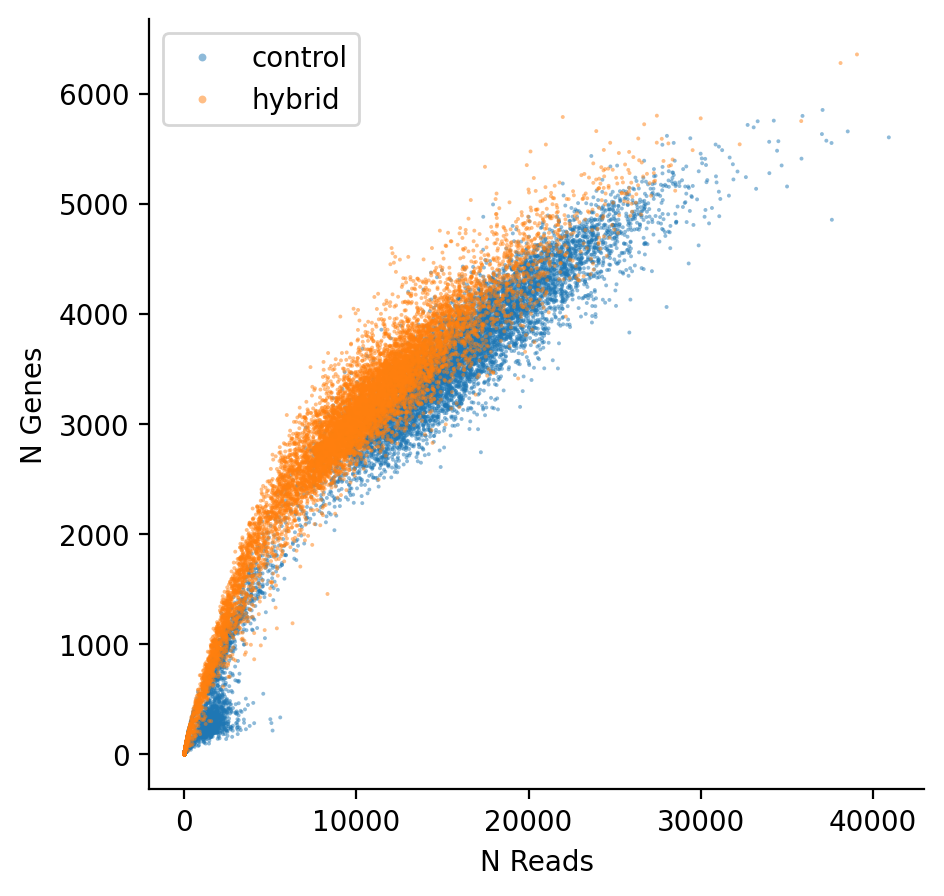

In [8]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    data=adata.obs,
    x='n_reads',
    y='n_genes',
    hue='batch',
    ec='none',
    s=2,
    alpha=0.5,
)

sns.move_legend(
    plt.gca(),
    title="",
    loc='best',
    markerscale=2,
)
plt.ylabel('N Genes')
plt.xlabel('N Reads')

sns.despine()

# Genes in only one condition

In [9]:
aggfunc = 'count_nonzero'

aggdata = sc.get.aggregate(
    adata,
    by='batch',
    func=aggfunc,
    axis='obs'
)

df = aggdata.to_df(layer=aggfunc).T
df = df.reset_index(names='gene_id')
df['gene_name'] = df['gene_id'].map(gene_map)
df.head()

,gene_id,control,hybrid,gene_name
0,SCYL3,497.0,785.0,NaN
1,C1orf112,600.0,717.0,NaN
2,FGR,4.0,8.0,NaN
3,CFH,480.0,1490.0,NaN
4,STPG1,1395.0,1628.0,NaN


In [10]:
df[['control', 'hybrid']].corr()

,control,hybrid
control,1.000000,0.979707
hybrid,0.979707,1.000000


In [11]:
df['diff'] = df['hybrid'] - df['control']
df['diff_abs'] = df['diff'].abs()

df.sort_values(by='diff_abs', ascending=False).head(25)

,gene_id,control,hybrid,gene_name,diff,diff_abs
5850,MYOD1,0.0,8614.0,NaN,8614.0,8614.0
31864,ESR1,9.0,6292.0,NaN,6283.0,6283.0
11425,FOS,6280.0,906.0,NaN,-5374.0,5374.0
32388,H1-4,2578.0,7910.0,NaN,5332.0,5332.0
32104,H1-3,1405.0,5881.0,NaN,4476.0,4476.0
31977,GMNN,5101.0,9450.0,NaN,4349.0,4349.0
35276,LINC-PINT,4507.0,8497.0,NaN,3990.0,3990.0
32499,H1-2,4405.0,8130.0,NaN,3725.0,3725.0
25860,DCBLD2,3064.0,6764.0,NaN,3700.0,3700.0
20703,RSAD2,3621.0,7248.0,NaN,3627.0,3627.0


In [12]:
# filter out MT and RP genes
print(f"Raw: {df.shape=}")
df = df[df['diff_abs'] < adata.shape[0] * 0.1]
print(f"Filtered: {df.shape=}")

df[['control', 'hybrid']].corr()

Raw: df.shape=(41389, 6)
Filtered: df.shape=(41230, 6)


,control,hybrid
control,1.000000,0.983675
hybrid,0.983675,1.000000


In [13]:
# break

In [14]:
# ?sc.pp.highly_variable_genes

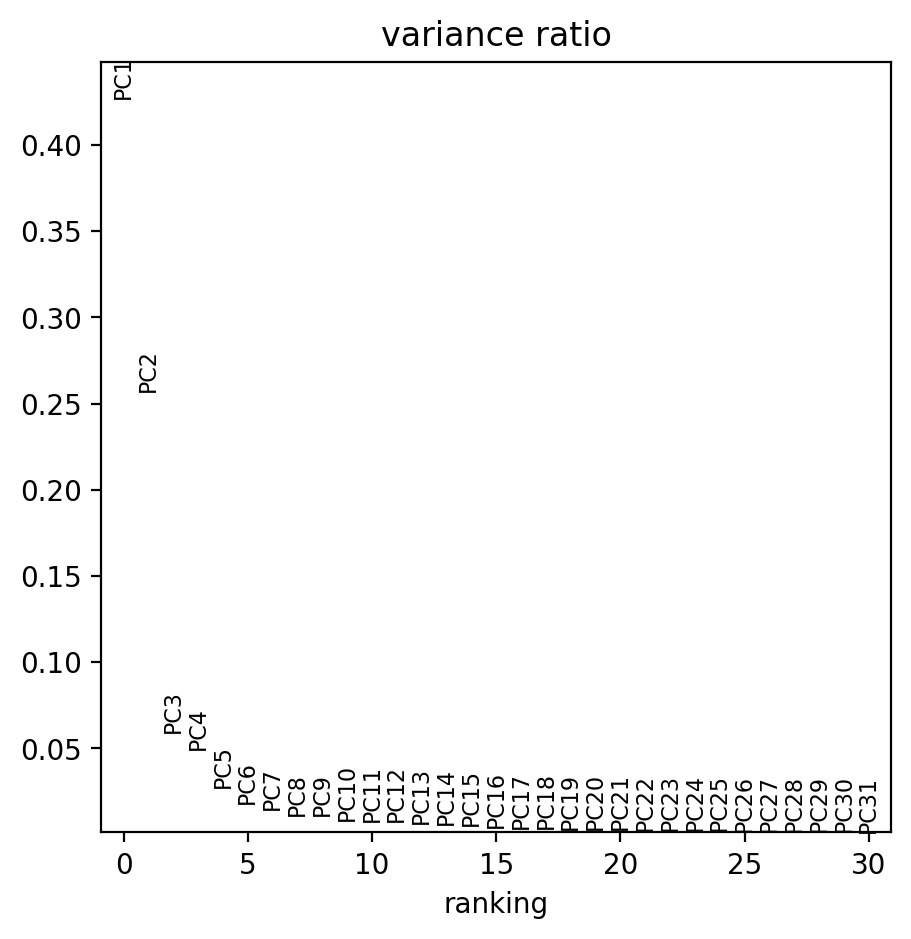

In [15]:
sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
    # n_top_genes=1500,
    
)

sc.pp.pca(
    adata,
)

sc.pl.pca_variance_ratio(adata)

In [16]:
adata

AnnData object with n_obs × n_vars = 22388 × 41389
    obs: 'batch', 'n_genes', 'n_reads'
    var: 'gene_name', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

... storing 'batch' as categorical
... storing 'gene_name' as categorical


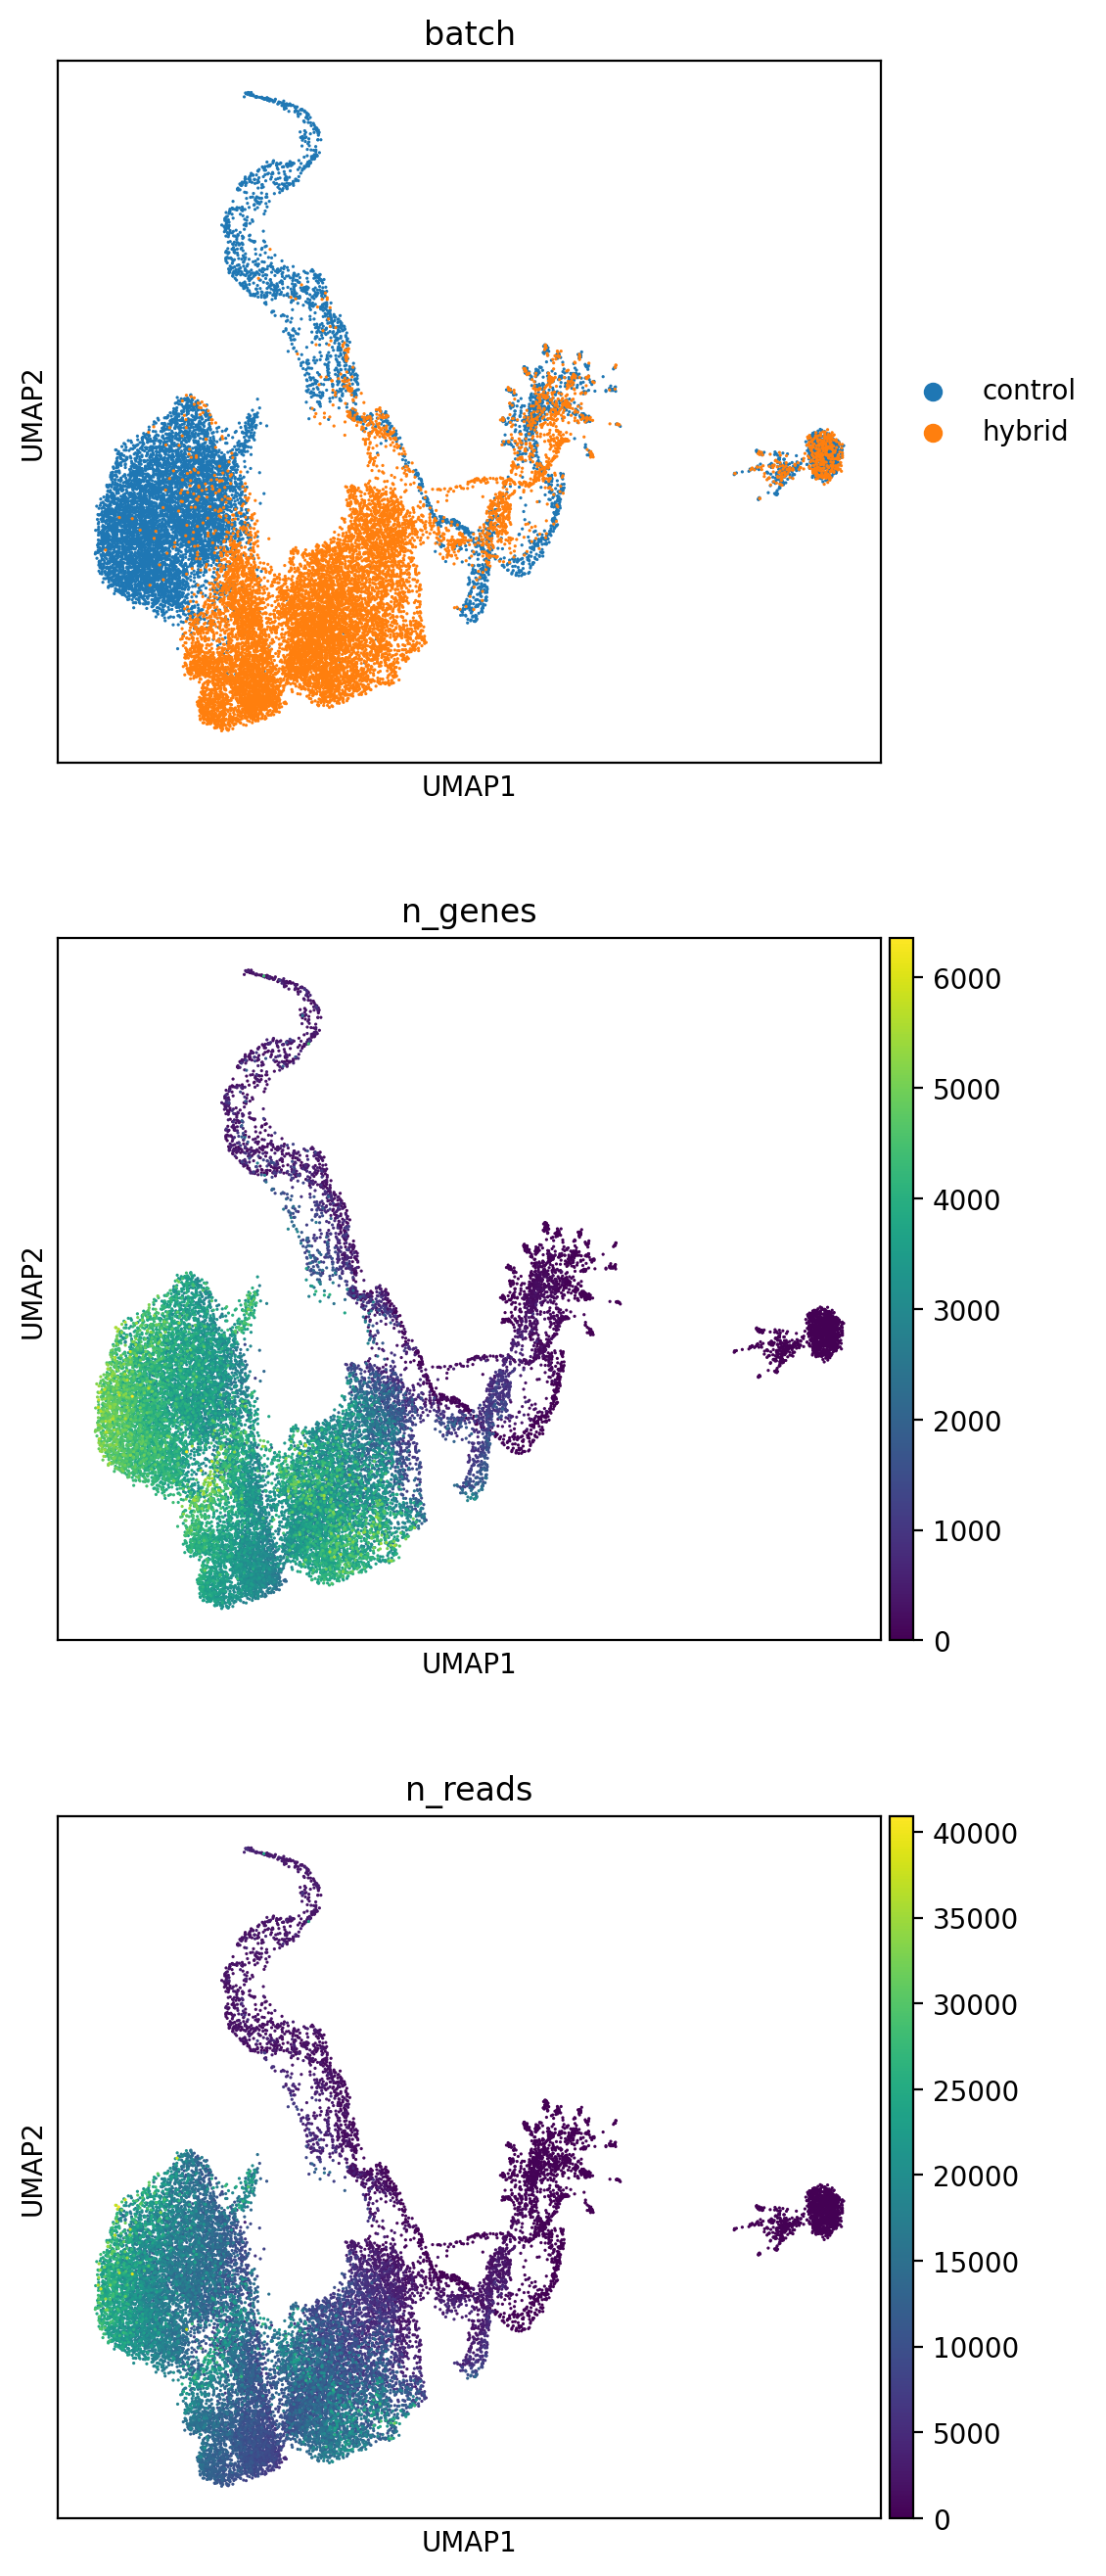

In [17]:
sc.pp.neighbors(
    adata,
)

sc.tl.umap(
    adata
)

sc.pl.umap(
    adata,
    color=['batch', 'n_genes', 'n_reads'],
    ncols=1,
)

In [18]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5, 5

sns.scatterplot(
    data=df,
    x='control',
    y='hybrid',
    s=2,
    ec='none',
)

# plt.yscale('log')
# plt.xscale('log')

In [ ]:
type(adata.X)

In [ ]:
adata.to_df().head()